<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

# 1. Load your dataset
# Ensure your index is set to a datetime format
# Correctly load the Air Quality UCI dataset specifying separator and decimal
air_quality_df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',')
# 1. Replace the fake 0.0 values with NaN (Not a Number)
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].replace(-200, np.nan)

# 2. Fill the gaps smoothly by connecting the last good point to the next good point
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].interpolate(method="linear")

# 3. Clean up edge cases (if a 0.0 happened to be the very first or last row)
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].bfill().ffill()
# Clean up empty columns and rows
# Drop columns that are entirely NaN (often at the end of this dataset)
air_quality_df = air_quality_df.dropna(axis=1, how='all')
# Drop rows where 'Date' or 'Time' are missing
air_quality_df = air_quality_df.dropna(subset=['Date', 'Time'])

# Combine 'Date' and 'Time' into a single Datetime index
# The format needs to match the data: day/month/year and hour.minute.second
air_quality_df['Datetime'] = pd.to_datetime(air_quality_df['Date'] + ' ' + air_quality_df['Time'], format='%d/%m/%Y %H.%M.%S')
air_quality_df = air_quality_df.set_index('Datetime').drop(columns=['Date', 'Time'])

# Convert relevant columns to numeric. Coerce errors to NaN and then drop rows with NaNs.
# We'll choose 'CO(GT)' as the target for decomposition.
target_column = 'CO(GT)'

# List of common numeric columns to ensure they are correctly parsed
numeric_cols = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
                'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
                'T', 'RH', 'AH']

for col in numeric_cols:
    if col in air_quality_df.columns:
        air_quality_df[col] = pd.to_numeric(air_quality_df[col], errors='coerce')

# Drop rows that have NaN in the target column after conversion
air_quality_df = air_quality_df.dropna(subset=[target_column])

# Ensure the index is sorted chronologically for seasonal_decompose
air_quality_df = air_quality_df.sort_index()
#print(air_quality_df['CO(GT)'].min())


0.1


In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(air_quality_df)


In [43]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window, 0])
    return np.array(X), np.array(y)


X, y = create_sequences(scaled_data, 20)

In [44]:
split = int(0.85 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
model = keras.Sequential()
model.add(keras.layers.LSTM(100, input_shape=(
    X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1))

model.compile(loss="huber", optimizer="adam", metrics=["mae"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100)            │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,701 (178.52 KB)

 Trainable params: 45,701 (178.52 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(X_train, y_train, epochs=30, batch_size=16)

Epoch 1/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0055 - mae: 0.0748
Epoch 2/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0023 - mae: 0.0497
Epoch 3/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0021 - mae: 0.0465
Epoch 4/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0018 - mae: 0.0429
Epoch 5/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0017 - mae: 0.0416
Epoch 6/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0017 - mae: 0.0411
Epoch 7/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0016 - mae: 0.0402
Epoch 8/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0016 - mae: 0.0393
Epoch 9/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0015 - mae: 0.0384
Epoch 10/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0015 - mae: 0.0379
Epoch 11/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0014 - mae: 0.0371
Epoch 12/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0014 - mae: 0.0372
Epoch 13/30
496/4

In [47]:
pred = model.predict(X_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


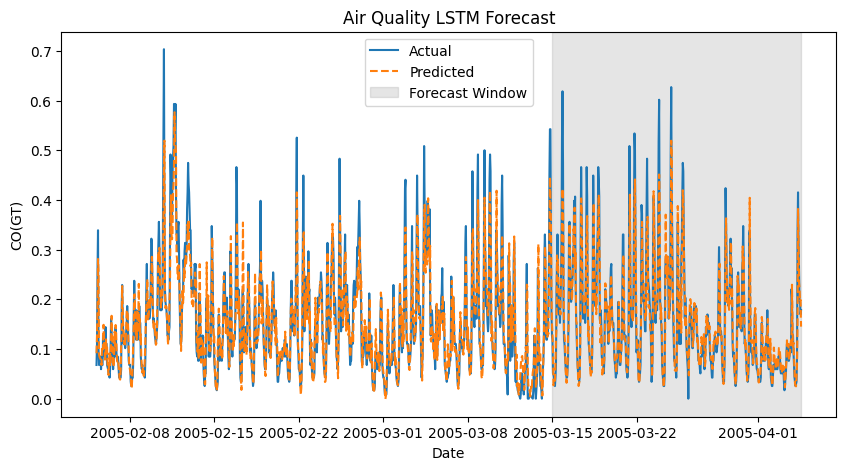

In [48]:
time = air_quality_df.index[-len(y_test):]

plt.figure(figsize=(10, 5))
plt.plot(time, y_test, label="Actual")
plt.plot(time, pred, linestyle="--", label="Predicted")

start_date = pd.to_datetime('2005-03-15')
end_date = air_quality_df.index[-1] # Grabs the last date from the index

plt.axvspan(start_date, end_date, color='gray', alpha=0.2, label='Forecast Window')
plt.title("Air Quality LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.legend()
plt.show()